In [11]:
import numpy as np
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import ndimage
import skimage.segmentation as seg
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.morphology import erosion
from skimage.measure import label
from transformers import SegformerForSemanticSegmentation, SegformerConfig


In [12]:
def build_target(instance_masks):
    h, w = instance_masks[0].shape
    target = np.zeros((h, w), dtype=np.uint8)
    for mask in instance_masks:
        mask = mask.astype(bool)
        eroded = erosion(mask, footprint=np.ones((3, 3)))
        boundary = mask & ~eroded
        target[mask] = 1
        target[boundary] = 2
    return target

In [13]:
torch.manual_seed(3)
train_dir = Path('../train')

#extracts all the images and masks
def load_image_and_mask(train_dir, imageid, target_size=256):
  folder_path = train_dir/imageid
  image_path = folder_path/'images'/ f'{imageid}.png'
  mask_path = folder_path/'masks'

  image = Image.open(image_path).convert('RGB')
  image = image.resize((target_size, target_size), Image.BILINEAR)
  image_array = np.array(image)

  instance_masks = []
  for maskname in os.listdir(mask_path):
    imask_path = mask_path/maskname
    mask = Image.open(imask_path).convert('L')
    mask = mask.resize((target_size, target_size), Image.NEAREST)
    instance_masks.append(np.array(mask) > 128)

  target = build_target(instance_masks)  # 0=background, 1=interior, 2=boundary
  return image_array, target

In [14]:
def probs_mask_to_instances_watershed(probs_mask):
    #this one can handle overlapping, sets the distance to the nearest background
    
    interior_prob = probs_mask[1]
    boundary_prob = probs_mask[2]

    # foreground = anything not background (interior + boundary)
    fg_mask = (probs_mask[0] < 0.5)

    # seeds = confident interior, away from boundaries
    seed_mask = (interior_prob > 0.7) & (boundary_prob < 0.3)
    markers = label(seed_mask)  # connected components -> one id per seed blob

    # distance transform on the foreground mask, same role as in your partner's code
    distance = ndimage.distance_transform_edt(fg_mask)

    # watershed floods from each seed outward, stopping at fg_mask boundary
    labeled_mask = watershed(-distance, markers, mask=fg_mask)

    return labeled_mask, labeled_mask.max()

In [15]:
#now we will convert all the arrays in tensor so as to be able to work later with the transformers

class MyDataset (Dataset):
  def __init__(self, train_dir, target_size):
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]
    self.normalize = T.Normalize(mean=imagenet_mean, std=imagenet_std)

    self.train_dir= train_dir
    self.target_size= target_size
    self.image_name= []

    all_data= os.listdir(train_dir)

    for files in all_data:

      fullpath= train_dir/files

      if os.path.isdir(fullpath):
        self.image_name.append(files)

    self.image_name.sort()


  def __len__(self):
    return len(self.image_name)

  def __getitem__(self, idx):
    image_id= self.image_name[idx]
    image, mask= load_image_and_mask(self.train_dir, image_id, self.target_size)

    #we change the order cause a tensor has first the channel,height, width, while numpy has height, width, channels
    image_tensor = torch.tensor(image, dtype=torch.float32).permute(2,0,1)/ 255.0
    image_tensor = self.normalize(image_tensor) 
    mask_tensor = torch.tensor(mask, dtype=torch.long)
    

    return image_tensor, mask_tensor


In [16]:
batch_size=8
target_size=256
full_dataset= MyDataset(train_dir, target_size=target_size)
#out of the training set we are getting some to form a validation group, to check overfitting and manage hyperparameters
train_size=int(0.85* len(full_dataset)) 
valid_size= len(full_dataset) - train_size

train_dataset, valid_dataset = random_split(full_dataset, [train_size, valid_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader  = DataLoader(valid_dataset, batch_size=batch_size)
# checking thefirst batch of data
# images_batch, masks_batch = next(iter(train_loader))

# print("=== ΕΛΕΓΧΟΣ ΔΙΑΣΤΑΣΕΩΝ ===")
# print("Images Batch Shape:", images_batch.shape)
# print("Masks Batch Shape:", masks_batch.shape)
# print("Τύπος Δεδομένων Εικόνας:", images_batch.dtype)
# print("Μέγιστη τιμή pixel εικόνας:", images_batch.max().item())
# print(f"Train: {train_size}  |  Val: {valid_size}")

In [17]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=3,
    ignore_mismatched_sizes=True
)
#checking
# predicted_masks, attention_weights = model(images_batch)

# print("=== ΤΕΛΙΚΟΣ ΕΛΕΓΧΟΣ ΜΟΝΤΕΛΟΥ ===")
# print("Είσοδος (Εικόνες):", images_batch.shape)
# print("Έξοδος (Προβλέψεις Μάσκας):", predicted_masks.shape)
# print("Σχήμα Attention Weights:", attention_weights.shape)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.bias                                         | UNEXPECTED | 
classifier.weight                                       | UNEXPECTED | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_fuse.weight                          

In [18]:
def compute_metrics(pred_logits, true_masks):
    #we introduce the metrics to have another criterion
    tiny_value = 1e-6
    preds = pred_logits.argmax(dim=1)  # [B, H, W] class indices

    # treat foreground as "interior or boundary" (i.e. not background)
    preds_fg = (preds != 0).float()
    trues_fg = (true_masks != 0).float()

    preds_flat = preds_fg.view(preds_fg.shape[0], -1)
    trues_flat = trues_fg.view(trues_fg.shape[0], -1)

    intersection = (preds_flat * trues_flat).sum(dim=1)
    pred_sum = preds_flat.sum(dim=1)
    true_sum = trues_flat.sum(dim=1)
    union = pred_sum + true_sum - intersection

    iou = (intersection + tiny_value) / (union + tiny_value)
    dsc = (2 * intersection + tiny_value) / (pred_sum + true_sum + tiny_value)
    pixel_acc = (preds == true_masks).float().view(preds.shape[0], -1).mean(dim=1)

    return iou.mean().item(), dsc.mean().item(), pixel_acc.mean().item()

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=1e-4)


epochs =20

def get_logits(model, images):
    out = model(images)
    logits = out.logits
    logits = F.interpolate(logits, size=images.shape[-2:], mode='bilinear', align_corners=False)
    return logits


for epoch in range(epochs):
    model.train() #training
    epoch_loss = 0.0
    
    for batch_idx, (images, true_masks) in enumerate(train_loader):
        images = images.to(device)
        true_masks = true_masks.to(device)

        optimizer.zero_grad()
        logits = get_logits(model, images)
        loss = criterion(logits, true_masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    model.eval()#evaluation of training and metrics
    val_loss =val_iou= val_dsc=val_pacc=0.0
    with torch.no_grad():
        for images, true_masks in valid_loader:
            images, true_masks = images.to(device), true_masks.to(device)
            logits = get_logits(model, images)
            val_loss += criterion(logits, true_masks).item()
            iou, dsc, pacc = compute_metrics(logits, true_masks)  
            val_iou += iou; val_dsc += dsc; val_pacc += pacc 
    avg_val_loss = val_loss / len(valid_loader)
    n=len(valid_loader)


    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}| IoU: {val_iou/n:.4f} | DSC: {val_dsc/n:.4f}")


print("Η εκπαίδευση ολοκληρώθηκε!")

Epoch [1/20] | Train Loss: 0.6467 | Val Loss: 0.3494| IoU: 0.7296 | DSC: 0.8346
Epoch [2/20] | Train Loss: 0.2939 | Val Loss: 0.1971| IoU: 0.7421 | DSC: 0.8405
Epoch [3/20] | Train Loss: 0.2085 | Val Loss: 0.1673| IoU: 0.7900 | DSC: 0.8727
Epoch [4/20] | Train Loss: 0.1686 | Val Loss: 0.1464| IoU: 0.8071 | DSC: 0.8834
Epoch [5/20] | Train Loss: 0.1498 | Val Loss: 0.1301| IoU: 0.7694 | DSC: 0.8580
Epoch [6/20] | Train Loss: 0.1414 | Val Loss: 0.1205| IoU: 0.7912 | DSC: 0.8732
Epoch [7/20] | Train Loss: 0.1312 | Val Loss: 0.1175| IoU: 0.8077 | DSC: 0.8833
Epoch [8/20] | Train Loss: 0.1229 | Val Loss: 0.1108| IoU: 0.8163 | DSC: 0.8887
Epoch [9/20] | Train Loss: 0.1182 | Val Loss: 0.1092| IoU: 0.8130 | DSC: 0.8865
Epoch [10/20] | Train Loss: 0.1145 | Val Loss: 0.1112| IoU: 0.8000 | DSC: 0.8776
Epoch [11/20] | Train Loss: 0.1109 | Val Loss: 0.1072| IoU: 0.8241 | DSC: 0.8935
Epoch [12/20] | Train Loss: 0.1066 | Val Loss: 0.1086| IoU: 0.8035 | DSC: 0.8804
Epoch [13/20] | Train Loss: 0.1070 | 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.3262744].


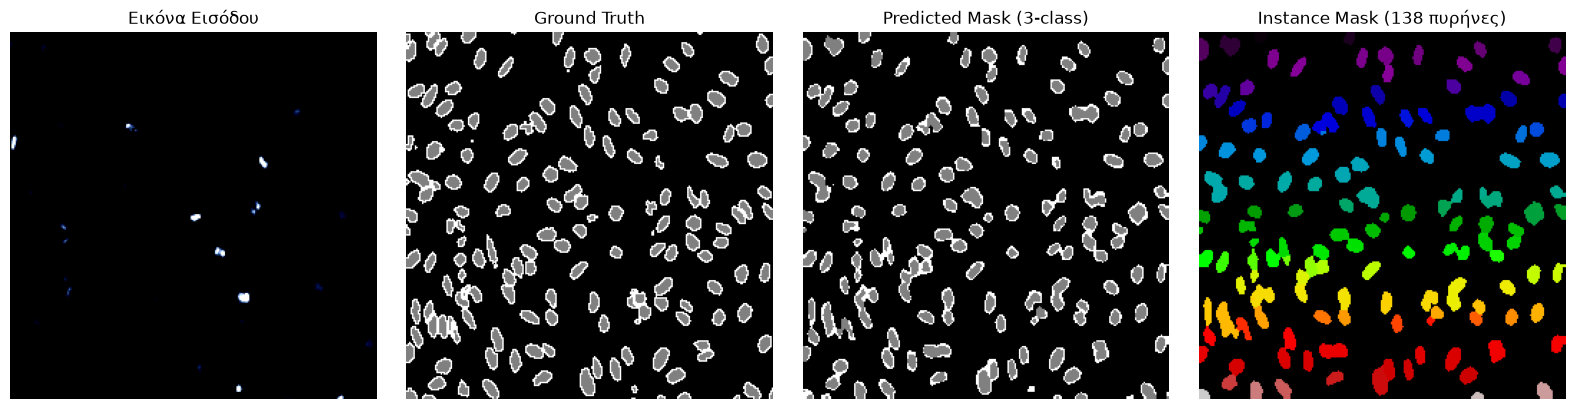

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..-0.34039208].


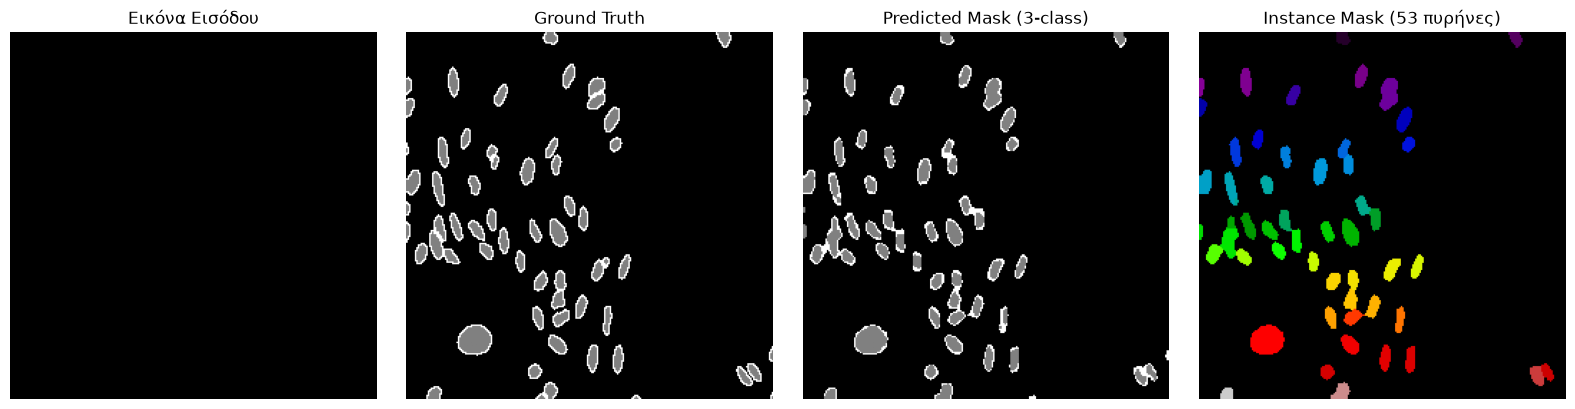

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.64].


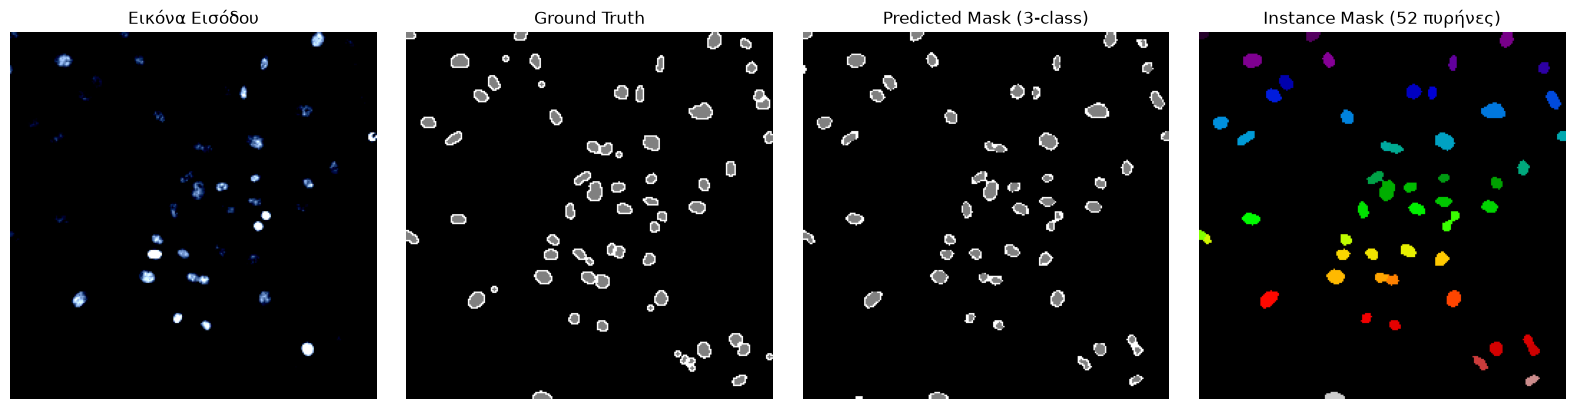

In [21]:
sample_images, sample_masks = next(iter(valid_loader))
sample_images = sample_images.to(device)

model.eval()
with torch.no_grad():
    pred_logits = get_logits(model, sample_images)
    pred_classes = pred_logits.argmax(dim=1)  # [B, H, W], values in {0,1,2}
    pred_probs = torch.softmax(pred_logits, dim=1)  # [B, 3, H, W]

for i in range(min(3, pred_classes.shape[0])):
    probs_np = pred_probs[i].cpu().numpy()  # [3, H, W]
    instance_mask, n = probs_mask_to_instances_watershed(probs_np)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(sample_images[i].cpu().permute(1, 2, 0))
    axes[0].set_title("Εικόνα Εισόδου")
    axes[1].imshow(sample_masks[i].cpu(), cmap='gray')
    axes[1].set_title("Ground Truth")
    axes[2].imshow(pred_classes[i].cpu(), cmap='gray')
    axes[2].set_title("Predicted Mask (3-class)")
    axes[3].imshow(instance_mask, cmap='nipy_spectral')
    axes[3].set_title(f"Instance Mask ({n} πυρήνες)")
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

In [25]:
# Store model parameters so we don't have to re-train every time
torch.save(model.state_dict(), "../trained-nets/bonus-finetuned-segformer")